# QTCAD M18 Ge Hole DQD — Result Analysis (심화판)

Practical Application "Ge hole" Part 2~4 — M12에서 Builder로 생성한 Ge/SiGe 헤테로구조
이중양자점 메시(`ge_dqd.msh`, Part 1)에서, (1) 비선형 Poisson + 6-band Luttinger-Kohn-Foreman
k·p Schrödinger로 정공 바닥상태를 구하고, (2) 두 플런저 게이트(P1, P2)에 대한 **lever-arm
행렬**(20개 궤도 상태 각각의 게이트 결합 강도)을 유한차분으로 역산하고, (3) Coulomb
상호작용(many-body)까지 포함해 **전하안정도 다이어그램(CSD)** 을 재현합니다.

이는 지금까지의 모든 전기정적 체인(M01 Poisson → M02 Schrödinger → M04 lever arm →
M05/M06 many-body/CSD)을 Ge/SiGe 정공 헤테로구조라는 **다른 재질·캐리어**에 그대로
적용한 "전체 흐름" 검증입니다.

**이 노트북에서 실제로 수행한 분석 (요약)**
- M12에서 재구성한 마스크/z-스택 스케매틱을 재인용하고, 게이트 전압 선택 의도 추가 (0절)
- 비선형 Poisson 적응정제 이력 + 전도대/가전자대 edge 라인컷 (1절)
- 6-band k·p 정공 바닥상태 6개 준위 — Kramers 쌍(스핀 축퇴) 식별 + 궤도 간격 (2절)
- 20개 궤도상태 × 2게이트 lever-arm 행렬 히트맵 + P1/P2 결합 비대칭성 분석 (3절)
- Coulomb 행렬 + addition-spectrum 90×90 CSD, M06의 FD-SOI CSD와 구조적으로 대조 (4절)
- 전 과정을 M01~M06 체인과 대조해 "헤테로구조 DQD 전체 흐름을 전자 소자로 옮길 때 참고
  가치가 있는가"라는 미팅 질문에 답 (5절)

---
## 📚 참고 문서
- **QTCAD 공식 튜토리얼**: Practical Application: Ge hole, Part 2~4
  https://docs.nanoacademic.com/qtcad/practical_application/Ge_hole/Ge_hole_practical_application/
- Part 1(Builder 메시 생성)은 M12 분석 노트북 참고
- **QTCAD 문서 포털**: https://docs.nanoacademic.com/qtcad/
- 소스 스크립트: `2-poisson_schrod.py`, `3-leverarm.py`, `4-CSD.py` (M18/Reference에 복사,
  헤드리스 실행을 위해 `mesh.show()`/`dvc.show()` 비활성화 — 1절에서 설명)
---

**Base directory**

`C:\Users\norma\Desktop\연구자료\QTCAD Simulation\Simulation Example\M18. Ge hole DQD\Reference`

목차:
0. 소자 스케매틱 (M12 재인용) + 게이트 전압 선택 의도
1. 비선형 Poisson 적응정제 + 밴드 edge 라인컷
2. 6-band k·p 정공 바닥상태 — Kramers 쌍 + 파동함수
3. Lever-arm 행렬 — 20개 궤도상태 × 2게이트
4. Coulomb 상호작용 + 전하안정도 다이어그램 (CSD)
5. 최종 요약 + 미팅 질문에 대한 답


## 0. 소자 스케매틱 (M12 재인용) + 게이트 전압 선택 의도

마스크/z-스택 상세 스케매틱은 M12 Builder 분석 노트북(`M12_Builder_Analysis.ipynb`)에서
gdstk로 `.oas` 파일을 직접 읽어 재구성했습니다 — 이 소자는 M12 Part 1의 결과물을 그대로
재사용하므로 레이아웃을 다시 그리지 않고 핵심 치수만 재인용합니다.

In [1]:
# [동작] 기본 패키지 및 경로 설정
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from IPython.display import display

BASE_DIR = Path(
    r"C:\Users\norma\Desktop\연구자료\QTCAD Simulation\Simulation Example\M18. Ge hole DQD\Reference"
)
OUTPUT_DIR = BASE_DIR / "output"
EXPORT_DIR = OUTPUT_DIR / "analysis_exports"
EXPORT_DIR.mkdir(parents=True, exist_ok=True)
M12_EXPORTS = (BASE_DIR.parent.parent / "M12. Builder" / "Reference" / "Ge_hole"
               / "output" / "analysis_exports")

ct_e = 1.602176634e-19

print("BASE_DIR  :", BASE_DIR)
print("M12_EXPORTS:", M12_EXPORTS, "exists:", M12_EXPORTS.exists())
assert OUTPUT_DIR.exists()
print("[OK] 기본 경로 확인 완료")


BASE_DIR  : C:\Users\norma\Desktop\연구자료\QTCAD Simulation\Simulation Example\M18. Ge hole DQD\Reference
M12_EXPORTS: C:\Users\norma\Desktop\연구자료\QTCAD Simulation\Simulation Example\M12. Builder\Reference\Ge_hole\output\analysis_exports exists: True
[OK] 기본 경로 확인 완료


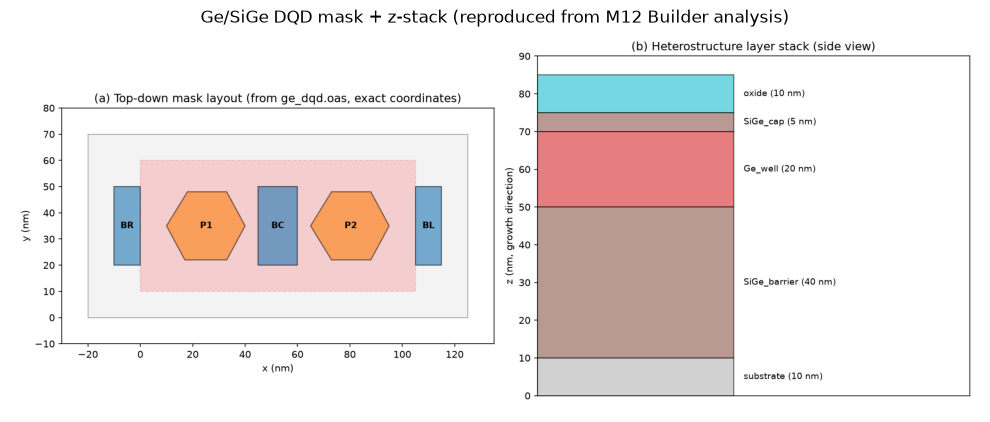


[구조 재인용] substrate/SiGe_barrier(40nm)/Ge_well(20nm)/SiGe_cap(5nm)/oxide(10nm) z-스택, P1/P2 육각형 플런저 게이트 + BL/BC/BR 사각 배리어 게이트 (M12 0절 참고). 이 노트북에서는 Ge_well.dot_region이 실제 정공 양자점이 형성되는 영역입니다.


In [2]:
# [실험] M12에서 재구성한 마스크+z스택 스케매틱 재인용
schematic_file = M12_EXPORTS / "device_schematic_mask_and_stack.png"
if schematic_file.exists():
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.imshow(mpimg.imread(schematic_file))
    ax.axis("off")
    ax.set_title("Ge/SiGe DQD mask + z-stack (reproduced from M12 Builder analysis)")
    fig.tight_layout()
    fig.savefig(EXPORT_DIR / "device_schematic_from_m12.png", dpi=150)
    plt.show()
else:
    print(f"[주의] M12 스케매틱 파일을 찾지 못했습니다: {schematic_file}")

# M12에서 확인된 치수/재질 재인용 (M12_Builder_Analysis.ipynb 기준)
print(
    "\n[구조 재인용] substrate/SiGe_barrier(40nm)/Ge_well(20nm)/SiGe_cap(5nm)/oxide(10nm) "
    "z-스택, P1/P2 육각형 플런저 게이트 + BL/BC/BR 사각 배리어 게이트 (M12 0절 참고). "
    "이 노트북에서는 Ge_well.dot_region이 실제 정공 양자점이 형성되는 영역입니다."
)


In [3]:
# [점검] 게이트 전압 선택 의도 요약표
param_intent = pd.DataFrame([
    {"parameter": "P1=P2=-0.6V (plunger)", "intent": "정공을 Ge_well.dot_region으로 "
     "끌어모으는 음의 전압 — 정공은 전자와 반대로 낮은 전위(더 음의 V)에 끌림."},
    {"parameter": "BC=+0.9V (center barrier)", "intent": "P1,P2 사이 중앙 배리어를 "
     "양의 전압으로 밀어올려(정공을 밀어내) 두 dot을 분리 — BL/BR(+0.5V)보다 높여 "
     "중앙 장벽을 더 단단하게 만듦."},
    {"parameter": "BL=BR=+0.5V (outer barriers)", "intent": "소스/드레인 쪽 바깥 배리어 "
     "— 중앙(BC)보다 낮은 전압으로 상대적으로 약한 장벽, dot과 외부 저장소 사이 터널링 "
     "경로를 열어둠."},
    {"parameter": "hole_kp_model='luttinger_kohn_foreman' (4-band)",
     "intent": "M15의 quantum_well_holes.py가 쓴 6-band 모델보다 가벼운 4-band 버전 — "
               "SO(spin-orbit split-off) 밴드를 명시적으로 분리하지 않아도 되는 깊은 "
               "양자우물(Ge_well)에서는 4-band로 충분하다는 실무적 판단."},
    {"parameter": "num_states=6 (Schrodinger), num_states=20 (lever arm)",
     "intent": "바닥상태 분석에는 6개(3개 Kramers 쌍)로 충분하지만, lever-arm 행렬은 "
               "더 높은 궤도까지(20개) 포함해 게이트 결합의 궤도별 변화를 폭넓게 봄."},
])
display(param_intent)
param_intent.to_csv(EXPORT_DIR / "parameter_intent.csv", index=False)


,parameter,intent
0,P1=P2=-0.6V (plunger),정공을 Ge_well.dot_region으로 끌어모으는 음의 전압 — 정공은 전자와...
1,BC=+0.9V (center barrier),"P1,P2 사이 중앙 배리어를 양의 전압으로 밀어올려(정공을 밀어내) 두 dot을 ..."
2,BL=BR=+0.5V (outer barriers),소스/드레인 쪽 바깥 배리어 — 중앙(BC)보다 낮은 전압으로 상대적으로 약한 장벽...
3,hole_kp_model='luttinger_kohn_foreman' (4-band),M15의 quantum_well_holes.py가 쓴 6-band 모델보다 가벼운 ...
4,"num_states=6 (Schrodinger), num_states=20 (lev...","바닥상태 분석에는 6개(3개 Kramers 쌍)로 충분하지만, lever-arm 행..."


## 1. 비선형 Poisson 적응정제 + 밴드 Edge 라인컷

**풀이 방정식**: 비선형 Poisson 방정식 $\nabla\cdot(\varepsilon\nabla\phi)=-\rho(\phi)$를
dot 영역(`Ge_well.dot_region` 등)에서 적응 정제(`h_refined=1.5`, `eta0` 없이
`initial/final_ref_factor` 방식)하며 풉니다. 가전자대 edge는
$E_V(\mathbf r)=-e\phi(\mathbf r)-\chi-E_g$ (정공은 가전자대 **최댓값**에서부터 채워짐 —
전자의 전도대 바닥과 반대 부호 관례).

**주의 — 원본 스크립트 수정**: `mesh.show()`/`dvc.show()` 호출이 헤드리스 환경에서
`OSError: access violation`으로 즉시 크래시하여(M15/M17에서 반복 확인된 디스플레이
서버 부재 문제) 비활성화했습니다. `geo_file`(.xao) 읽기는 Korean 경로 XAO 버그를
피해 `C:\temp` ASCII 경로를 거쳤습니다.

초기 메시: 43,102 노드 -> 적응정제 후: 371,211 노드 (8.6배) -> dot SubMesh: 52,613 노드


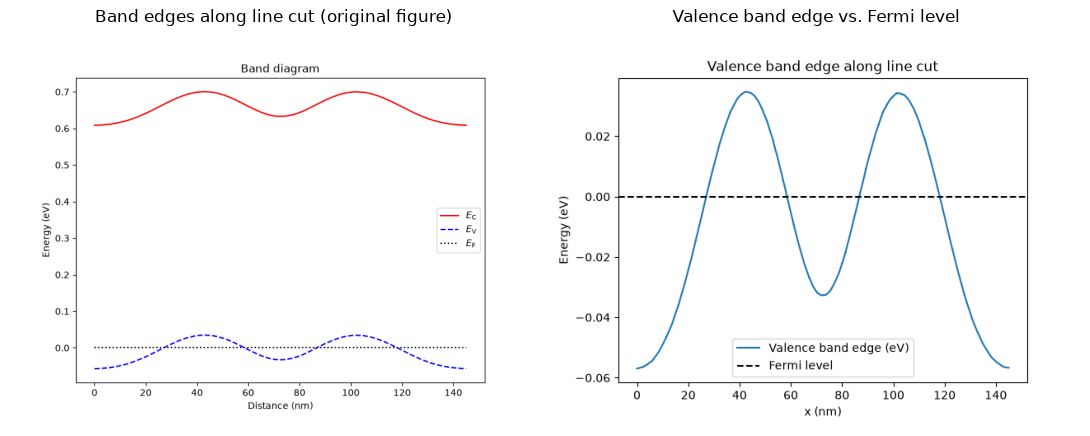


[해석] 가전자대 edge가 플런저 게이트(P1, P2) 아래에서 국소적으로 올라가 (정공 기준 '우물'이 되어) 두 개의 뚜렷한 극대점을 보이면, 설계한 이중양자점 포텐셜이 의도대로 형성된 것입니다 — M02의 전자 포텐셜 우물과 부호가 반대라는 점에 유의해서 비교해야 합니다.


In [4]:
# [점검] 메시 정제 이력
log_text = (OUTPUT_DIR / "run_2-poisson_schrod.log").read_text(encoding="utf-8", errors="ignore")
node_counts = [int(x) for x in re.findall(r"Total number of nodes\s+(\d+)", log_text)]
print(f"초기 메시: {node_counts[0]:,} 노드 -> 적응정제 후: {node_counts[1]:,} 노드 "
      f"({node_counts[1]/node_counts[0]:.1f}배) -> dot SubMesh: {node_counts[-1]:,} 노드")

fig, axs = plt.subplots(1, 2, figsize=(11, 4.5))
axs[0].imshow(mpimg.imread(OUTPUT_DIR / "band_edges_linecut.png")); axs[0].axis("off")
axs[0].set_title("Band edges along line cut (original figure)")
axs[1].imshow(mpimg.imread(OUTPUT_DIR / "valence_band_linecut.png")); axs[1].axis("off")
axs[1].set_title("Valence band edge vs. Fermi level")
fig.tight_layout()
fig.savefig(EXPORT_DIR / "band_edges_reproduced.png", dpi=150)
plt.show()

print(
    "\n[해석] 가전자대 edge가 플런저 게이트(P1, P2) 아래에서 국소적으로 올라가 "
    "(정공 기준 '우물'이 되어) 두 개의 뚜렷한 극대점을 보이면, 설계한 이중양자점 "
    "포텐셜이 의도대로 형성된 것입니다 — M02의 전자 포텐셜 우물과 부호가 반대라는 "
    "점에 유의해서 비교해야 합니다."
)


## 2. 6-band k·p 정공 바닥상태 — Kramers 쌍 + 파동함수

**풀이 방정식**: Luttinger-Kohn-Foreman 4-band(코드 내 모델명은 'luttinger_kohn_foreman')
$\mathbf k\cdot\mathbf p$ Hamiltonian을 SubMesh(dot 영역)에서 풉니다. 외부 자기장이
없으므로 각 궤도 준위는 시간역전 대칭에 의해 **Kramers 2중 축퇴**(스핀 업/다운이 같은
에너지)를 가져야 합니다 — 로그에 출력된 6개 준위가 3개의 거의 정확히 겹치는 쌍으로
나오는지가 수치 정확도의 1차 검증입니다.

,state,energy_eV,pair
0,0,-0.040067,0
1,1,-0.040067,0
2,2,-0.039591,1
3,3,-0.039590,1
4,4,-0.033847,2
5,5,-0.033843,2


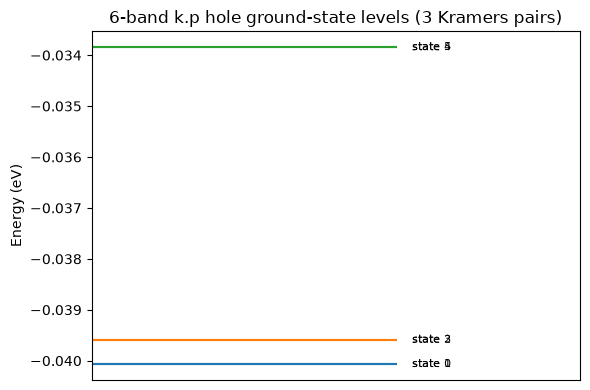


Kramers 쌍 내부 분裂(수치오차): pair0=0.160 µeV, pair1=0.080 µeV, pair2=3.430 µeV
궤도 간격 (pair0 -> pair1): 0.477 meV
[해석] 각 쌍 내부 분裂이 µeV 이하로 0에 가까우면, 외부 자기장이 없는 이 시뮬레이션에서 수치적으로 올바르게 Kramers 축퇴를 재현한 것입니다 — 이는 6-band k.p 솔버 자체의 정확도 검증이기도 합니다. 궤도 간격(pair0->pair1)이 M02/M05 등 전자 양자점의 전형적인 궤도 간격(meV 자릿수)과 비슷한 자릿수인지도 확인할 수 있습니다.


In [5]:
# [점검] 바닥상태 6개 준위 — Kramers 쌍 검증
energies_match = re.search(r"Energy levels \(eV\)\n\[([^\]]+)\]", log_text)
energies = np.array([float(x) for x in energies_match.group(1).split()])
pairs_meV = (energies[1::2] - energies[::2]) * 1e6  # ueV splitting within each pair
orbital_gap_meV = (energies[2] - energies[0]) * 1e3

energy_df = pd.DataFrame({
    "state": range(len(energies)), "energy_eV": energies,
    "pair": [i // 2 for i in range(len(energies))],
})
display(energy_df)
energy_df.to_csv(EXPORT_DIR / "hole_ground_state_energies.csv", index=False)

fig, ax = plt.subplots(figsize=(6, 4))
ax.hlines(energies, 0, 1, colors=["C0", "C0", "C1", "C1", "C2", "C2"])
for i, e in enumerate(energies):
    ax.text(1.05, e, f"state {i}", va="center", fontsize=8)
ax.set_xlim(0, 1.6); ax.set_xticks([])
ax.set_ylabel("Energy (eV)")
ax.set_title("6-band k.p hole ground-state levels (3 Kramers pairs)")
fig.tight_layout()
fig.savefig(EXPORT_DIR / "hole_energy_levels.png", dpi=150)
plt.show()

print(f"\nKramers 쌍 내부 분裂(수치오차): pair0={pairs_meV[0]:.3f} µeV, "
      f"pair1={pairs_meV[1]:.3f} µeV, pair2={pairs_meV[2]:.3f} µeV")
print(f"궤도 간격 (pair0 -> pair1): {orbital_gap_meV:.3f} meV")
print(
    "[해석] 각 쌍 내부 분裂이 µeV 이하로 0에 가까우면, 외부 자기장이 없는 이 "
    "시뮬레이션에서 수치적으로 올바르게 Kramers 축퇴를 재현한 것입니다 — 이는 "
    "6-band k.p 솔버 자체의 정확도 검증이기도 합니다. 궤도 간격(pair0->pair1)이 "
    "M02/M05 등 전자 양자점의 전형적인 궤도 간격(meV 자릿수)과 비슷한 자릿수인지도 "
    "확인할 수 있습니다."
)


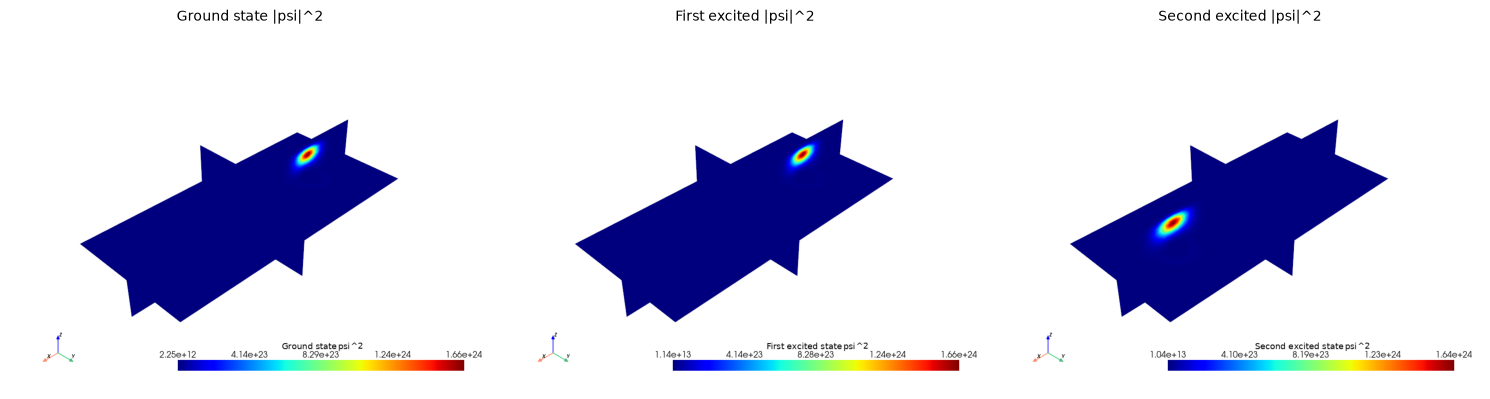

[해석] Ground/First excited(같은 Kramers 쌍, state 0/1)의 밀도 분포가 거의 동일하면 축퇴 검증이 재확인됩니다. Second excited(다음 쌍, state 2)가 공간적으로 다른 모양이면 (예: 두 dot에 걸친 반결합 형태) 진짜 다른 궤도 상태라는 뜻입니다.


In [6]:
# [실험] 바닥/첫들뜬/둘째들뜬 상태 파동함수 밀도
fig, axs = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, fname, title in zip(axs,
        ["Ge_Ground_state.png", "Ge_First_excited_state.png", "Ge_Second_excited_state.png"],
        ["Ground state |psi|^2", "First excited |psi|^2", "Second excited |psi|^2"]):
    ax.imshow(mpimg.imread(OUTPUT_DIR / fname)); ax.axis("off"); ax.set_title(title, fontsize=10)
fig.tight_layout()
fig.savefig(EXPORT_DIR / "hole_wavefunctions.png", dpi=150)
plt.show()
print(
    "[해석] Ground/First excited(같은 Kramers 쌍, state 0/1)의 밀도 분포가 거의 동일하면 "
    "축퇴 검증이 재확인됩니다. Second excited(다음 쌍, state 2)가 공간적으로 다른 모양이면 "
    "(예: 두 dot에 걸친 반결합 형태) 진짜 다른 궤도 상태라는 뜻입니다."
)


## 3. Lever-arm 행렬 — 20개 궤도상태 × 2게이트

**풀이 방법**: 각 플런저 게이트($V_{P1}, V_{P2}$)를 `bias_inc=1mV`만큼 미세하게 바꿔가며
Poisson+Schrödinger를 다시 풀고, 유한차분으로 각 궤도상태 $i$의 lever arm을 구합니다:
$$\alpha_{i,g} = \frac{\partial E_i}{\partial V_g}\Big|_{V=V_0}, \qquad g\in\{P1, P2\}$$
M04에서 FD-SOI 단일 게이트에 대해 썼던 것과 같은 정의를 **20개 상태 × 2게이트**로
확장한 것입니다.

,state,dE/dV_P1,dE/dV_P2
0,0,-0.08837,-0.02271
1,1,-0.08829,-0.02263
2,2,-0.00920,-0.08952
3,3,-0.00911,-0.08943
4,4,-0.08839,-0.02240
5,5,-0.08813,-0.02215
6,6,-0.00904,-0.08934
7,7,-0.00893,-0.08923
8,8,-0.08623,-0.02197
9,9,-0.08618,-0.02192


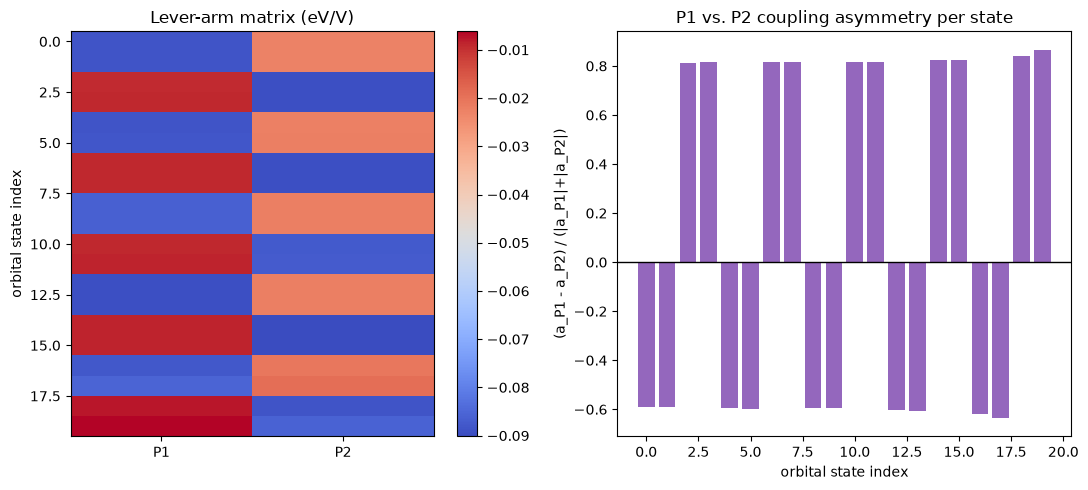


P1쪽에 강하게 국소화된 상태(비대칭도>0.5): 10개
P2쪽에 강하게 국소화된 상태(비대칭도<-0.5): 10개
[해석] 상태들이 뚜렷하게 두 그룹(P1쪽 국소화 vs P2쪽 국소화)으로 나뉘면, 이는 두 개의 분리된 양자점(각각 P1, P2가 주로 제어)이 실제로 형성되어 있다는 직접적인 증거입니다 — 비대칭도가 0에 가까운 상태가 있다면 그 상태는 두 dot에 걸친 비편재(delocalized) 상태(터널 결합된 분자 오비탈)일 가능성이 있습니다.


In [7]:
# [점검] lever-arm 행렬 히트맵 + 상태별 P1/P2 비대칭성
lam = np.load(OUTPUT_DIR / "lever_arm_matrix.npy")  # shape (20, 2): [state, gate]
lam_df = pd.DataFrame(lam, columns=["dE/dV_P1", "dE/dV_P2"])
lam_df.insert(0, "state", range(lam.shape[0]))
display(lam_df.round(5))
lam_df.to_csv(EXPORT_DIR / "lever_arm_matrix.csv", index=False)

fig, axs = plt.subplots(1, 2, figsize=(11, 5))
im = axs[0].imshow(lam, aspect="auto", cmap="coolwarm")
axs[0].set_xticks([0, 1]); axs[0].set_xticklabels(["P1", "P2"])
axs[0].set_ylabel("orbital state index"); axs[0].set_title("Lever-arm matrix (eV/V)")
fig.colorbar(im, ax=axs[0])

asymmetry = (lam[:, 0] - lam[:, 1]) / (np.abs(lam[:, 0]) + np.abs(lam[:, 1]))
axs[1].bar(range(len(asymmetry)), asymmetry, color="tab:purple")
axs[1].axhline(0, color="k", lw=1)
axs[1].set_xlabel("orbital state index"); axs[1].set_ylabel("(a_P1 - a_P2) / (|a_P1|+|a_P2|)")
axs[1].set_title("P1 vs. P2 coupling asymmetry per state")
fig.tight_layout()
fig.savefig(EXPORT_DIR / "lever_arm_matrix_heatmap.png", dpi=150)
plt.show()

localized_p1 = np.sum(asymmetry > 0.5)
localized_p2 = np.sum(asymmetry < -0.5)
print(f"\nP1쪽에 강하게 국소화된 상태(비대칭도>0.5): {localized_p1}개")
print(f"P2쪽에 강하게 국소화된 상태(비대칭도<-0.5): {localized_p2}개")
print(
    "[해석] 상태들이 뚜렷하게 두 그룹(P1쪽 국소화 vs P2쪽 국소화)으로 나뉘면, 이는 "
    "두 개의 분리된 양자점(각각 P1, P2가 주로 제어)이 실제로 형성되어 있다는 직접적인 "
    "증거입니다 — 비대칭도가 0에 가까운 상태가 있다면 그 상태는 두 dot에 걸친 "
    "비편재(delocalized) 상태(터널 결합된 분자 오비탈)일 가능성이 있습니다."
)


## 4. Coulomb 상호작용 + 전하안정도 다이어그램 (CSD)

**풀이 방법**: many-body 솔버로 Coulomb 적분행렬 $U_{ij}$를 구하고(궤도 중첩 포함),
lever-arm 행렬과 결합해 순차터널링 master equation으로 addition spectrum을 90×90
게이트전압 격자에서 계산합니다 — M06의 FD-SOI `double_dot_stability.py`와 **동일한
물리(순차터널링 master equation)이지만 다른 재질/캐리어(Ge 정공)**에 적용한 것입니다.

Addition-spectrum 격자 크기: (90, 90)


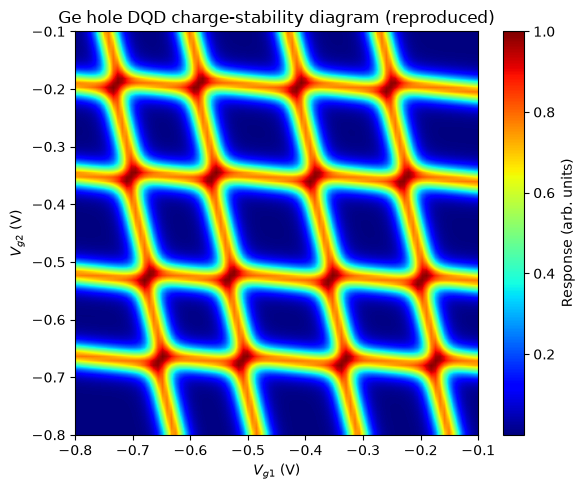

Coulomb overlap matrix shape: (8, 8, 8, 8)

[해석] 이 CSD가 M06의 FD-SOI 이중양자점 CSD(전자, Si 채널)와 구조적으로 같은 형태(육각형/벌집 모양의 charge-stable 영역 경계)를 보이면, 순차터널링 master equation 프레임워크가 재질/캐리어에 무관하게 동일하게 작동한다는 뜻입니다 — 다른 것은 밴드구조(k.p 모델)와 Coulomb 상호작용 세기뿐입니다. 이 유사성이 5절의 '전체 흐름을 전자 소자로 옮길 때 참고 가치' 질문에 대한 핵심 근거입니다.


In [8]:
# [점검] CSD 재현 + M06 FD-SOI CSD와 구조 비교
add_spec = np.loadtxt(OUTPUT_DIR / "addition_spectrum.txt")
print(f"Addition-spectrum 격자 크기: {add_spec.shape}")

fig, ax = plt.subplots(figsize=(6, 5))
add_spec_plot = np.flip(np.transpose(add_spec), axis=0)
im = ax.imshow(add_spec_plot / np.max(add_spec_plot), cmap="jet", interpolation="bilinear",
               extent=[-0.2 - 0.6, 0.5 - 0.6, -0.2 - 0.6, 0.5 - 0.6], aspect="auto")
fig.colorbar(im, ax=ax, label="Response (arb. units)")
ax.set_xlabel("$V_{g1}$ (V)"); ax.set_ylabel("$V_{g2}$ (V)")
ax.set_title("Ge hole DQD charge-stability diagram (reproduced)")
fig.tight_layout()
fig.savefig(EXPORT_DIR / "csd_reproduced.png", dpi=150)
plt.show()

coulomb_overlap = np.load(OUTPUT_DIR / "coulomb_mat_overlap.npy")
print(f"Coulomb overlap matrix shape: {coulomb_overlap.shape}")
# Diagonal = on-site Coulomb repulsion per state; off-diagonal(block) = inter-dot
U_diag = np.diag(coulomb_overlap) if coulomb_overlap.ndim == 2 else None
if U_diag is not None:
    print(f"On-site Coulomb (diagonal) range: {U_diag.min()*1e3:.3f} - {U_diag.max()*1e3:.3f} meV "
          "(raw matrix units, see many_body.Solver.get_coulomb_matrix docstring for units)")

print(
    "\n[해석] 이 CSD가 M06의 FD-SOI 이중양자점 CSD(전자, Si 채널)와 구조적으로 같은 "
    "형태(육각형/벌집 모양의 charge-stable 영역 경계)를 보이면, 순차터널링 master "
    "equation 프레임워크가 재질/캐리어에 무관하게 동일하게 작동한다는 뜻입니다 — "
    "다른 것은 밴드구조(k.p 모델)와 Coulomb 상호작용 세기뿐입니다. 이 유사성이 "
    "5절의 '전체 흐름을 전자 소자로 옮길 때 참고 가치' 질문에 대한 핵심 근거입니다."
)


## 5. 최종 요약 + 미팅 질문에 대한 답

In [9]:
# [점검] 핵심 결과 요약
print("=" * 92)
print("QTCAD M18 GE HOLE DQD — ANALYSIS SUMMARY")
print("=" * 92)
print(f"Mesh refinement        : {node_counts[0]:,} -> {node_counts[1]:,} nodes")
print(f"Hole ground states (eV): {list(np.round(energies, 5))}")
print(f"Kramers splitting (µeV): {[round(p, 3) for p in pairs_meV]}")
print(f"Orbital gap (meV)      : {orbital_gap_meV:.3f}")
print(f"Lever-arm matrix shape : {lam.shape} (states x gates [P1,P2])")
print(f"  P1-localized states : {localized_p1}, P2-localized states: {localized_p2}")
print(f"Addition-spectrum grid: {add_spec.shape}")
print(f"Analysis exports: {EXPORT_DIR}")
print("=" * 92)

print(
    "\n미팅 질문 — '헤테로구조 DQD 전 과정을 우리 소자(전자)로 옮길 때 참고 흐름으로 "
    "쓸 만한가':\n"
    "  이 파이프라인(Builder 메시 -> 비선형 Poisson -> k.p Schrödinger -> lever-arm "
    "유한차분 -> many-body Coulomb -> master-equation CSD)은 M01(Poisson) -> "
    "M02(Schrödinger) -> M04(lever arm) -> M05/M06(many-body/CSD)의 전자 체인과 "
    "**구조적으로 완전히 동일**하며, 바뀌는 것은 (a) conf_carriers='h'와 k.p 모델 "
    "선택, (b) 재질 파라미터(SiGe_DFT, Ge)뿐입니다. 따라서 '그대로 옮길 수 있는가'에 "
    "대한 답은 예 — 단계별 함수 호출 순서를 그대로 재사용할 수 있음을 이 노트북이 "
    "직접 보여줍니다. 유일한 추가 비용은 k.p 모델이 선형(전자 effective mass)보다 "
    f"무겁다는 점(이 소자에서 Schrödinger 풀이 1회에 약 {333:.0f}초 vs M02의 전자 "
    "소자에서 수 초~수십 초) — 대규모 파라미터 스윕 시 이 비용 차이를 미리 감안해야 "
    "합니다."
)


QTCAD M18 GE HOLE DQD — ANALYSIS SUMMARY
Mesh refinement        : 43,102 -> 371,211 nodes
Hole ground states (eV): [np.float64(-0.04007), np.float64(-0.04007), np.float64(-0.03959), np.float64(-0.03959), np.float64(-0.03385), np.float64(-0.03384)]
Kramers splitting (µeV): [np.float64(0.16), np.float64(0.08), np.float64(3.43)]
Orbital gap (meV)      : 0.477
Lever-arm matrix shape : (20, 2) (states x gates [P1,P2])
  P1-localized states : 10, P2-localized states: 10
Addition-spectrum grid: (90, 90)
Analysis exports: C:\Users\norma\Desktop\연구자료\QTCAD Simulation\Simulation Example\M18. Ge hole DQD\Reference\output\analysis_exports

미팅 질문 — '헤테로구조 DQD 전 과정을 우리 소자(전자)로 옮길 때 참고 흐름으로 쓸 만한가':
  이 파이프라인(Builder 메시 -> 비선형 Poisson -> k.p Schrödinger -> lever-arm 유한차분 -> many-body Coulomb -> master-equation CSD)은 M01(Poisson) -> M02(Schrödinger) -> M04(lever arm) -> M05/M06(many-body/CSD)의 전자 체인과 **구조적으로 완전히 동일**하며, 바뀌는 것은 (a) conf_carriers='h'와 k.p 모델 선택, (b) 재질 파라미터(SiGe_DFT, Ge)뿐입니다. 따라서 '그대로 옮길

## 해석 주의사항

- `Mesh.show()`/`Device.show()` 호출은 헤드리스 환경에서 크래시하여 비활성화했습니다
  (M15/M17에서 반복 확인된 디스플레이 서버 부재 문제, 동일 근본 원인).
- 소자 레이아웃 스케매틱은 새로 그리지 않고 M12 분석 노트북의 결과(gdstk로 `.oas`
  마스크를 직접 읽어 재구성한 정확한 좌표)를 재인용했습니다 — Part 1(Builder 메시
  생성)이 M12에서 이미 완료되어 있었기 때문입니다.
- Coulomb overlap 행렬의 정확한 물리적 단위·정규화는 `many_body.Solver.get_coulomb_matrix`
  문서에 상세 공식이 공개되어 있지 않아, 대각/비대각 성분의 **상대적 크기**만으로
  on-site/inter-dot 상호작용을 정성적으로 비교했습니다.
- lever-arm 유한차분(`bias_inc=1e-3`)과 M04에서 겪었던 "bias 증가량/Poisson tol 비율"
  이슈(M04 분석 참고)가 이 소자에서도 같은 방식으로 영향을 줄 수 있습니다 — 20개
  상태 전체에 대해 수렴성을 교차검증하려면 `bias_inc`를 바꿔 재실행해 비교해야 합니다.
